In [10]:
import numpy as np
import matplotlib.pyplot as plt
import camb
from camb import model
from scipy.signal import savgol_filter

plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'

plt.rc('xtick', labelsize=12) 
plt.rc('ytick', labelsize=12)
plt.rc('font', size=14)
plt.rc('axes', labelsize=16)

path_to_fig = r'C:\EPFL\MA4\code\PDM2026\figures'

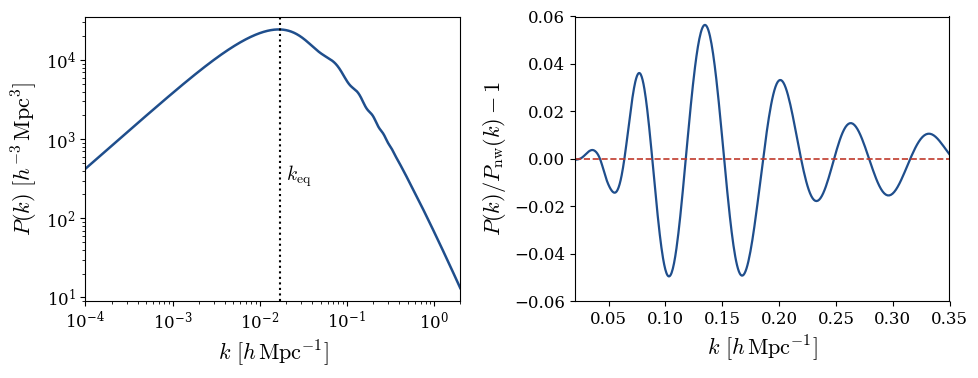

In [ ]:
"""
Generate the linear matter power spectrum P(k) using CAMB,
with a zoomed-in panel showing the BAO wiggles against a
smooth "no-wiggle" reference spectrum.
"""

# --- Cosmological parameters (Planck 2018-like flat LCDM) ---
pars = camb.CAMBparams()
pars.set_cosmology(H0=67.4, ombh2=0.0224, omch2=0.120, mnu=0.06, omk=0, tau=0.054)
pars.InitPower.set_params(As=2.1e-9, ns=0.965)
pars.set_matter_power(redshifts=[0.0], kmax=2.0)
pars.NonLinear = model.NonLinear_none

results = camb.get_results(pars)
kh, z, pk = results.get_matter_power_spectrum(minkh=1e-4, maxkh=2.0, npoints=2000)
pk = pk[0]  # z=0

# --- Build a smooth "no-wiggle" reference via Savitzky-Golay filter in log-log space ---
logk = np.log10(kh)
logpk = np.log10(pk)
window = 301  # must be odd
logpk_smooth = savgol_filter(logpk, window_length=window, polyorder=4)
pk_smooth = 10**logpk_smooth

# --- Figure with two panels ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left panel: full shape, log-log
ax = axes[0]
ax.loglog(kh, pk, color='#1f4e8c', lw=1.8)
ax.set_xlabel(r'$k \ [h\,\mathrm{Mpc}^{-1}]$', fontsize=16)
ax.set_ylabel(r'$P(k) \ [h^{-3}\,\mathrm{Mpc}^3]$', fontsize=16)
# ax.set_title('Linear matter power spectrum', fontsize=12)
ax.axvline(0.0173, color='black', lw=1.5, ls=':')
ax.text(0.0173*1.15, 3e2, r'$k_{\rm eq}$', fontsize=14, color='black')
ax.set_xlim(1e-4, 2.0)
# ax.grid(alpha=0.5, which='both')

# Right panel: BAO wiggles as fractional deviation from the smooth spectrum
ax = axes[1]
mask = (kh > 0.02) & (kh < 0.35)
wiggle_frac = pk[mask] / pk_smooth[mask] - 1.0
ax.plot(kh[mask], wiggle_frac, color='#1f4e8c', lw=1.6)
ax.axhline(0, color='#c0392b', lw=1.2, ls='--')
ax.set_xlabel(r'$k \ [h\,\mathrm{Mpc}^{-1}]$', fontsize=16)
ax.set_ylabel(r'$P(k)/P_{\rm nw}(k) - 1$', fontsize=16)
# ax.set_title('BAO wiggles (fractional)', fontsize=12)
# ax.grid(alpha=0.25)
ax.set_xlim(0.02, 0.35)
ax.set_ylim(-0.06, 0.06)

plt.tight_layout()
# plt.savefig(path_to_fig + r'\illustrations\power_spectrum_bao.pdf', dpi=200, bbox_inches='tight')

np.savez('pk_data.npz', kh=kh, pk=pk, pk_smooth=pk_smooth)

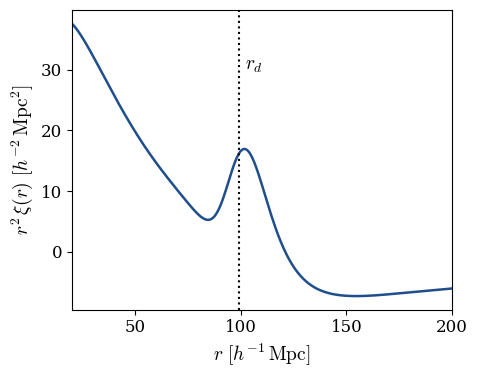

In [39]:
"""
Compute the two-point correlation function xi(r) from the CAMB linear P(k)
via the Wiener-Khinchin relation, and plot r^2 xi(r) to reveal the BAO peak.
Requires pk_data.npz saved by the power spectrum script above.
"""
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson

data = np.load('pk_data.npz')
kh, pk = data['kh'], data['pk']

def xi_of_r(r, k, pk):
    integrand = k**2 * pk * np.sin(k * r) / (k * r) * np.exp(-(k*2.0)**2)
    return simpson(integrand, k) / (2 * np.pi**2)

r_vals = np.linspace(20, 200, 400)
xi_vals = np.array([xi_of_r(r, kh, pk) for r in r_vals])

h = 0.674  # match H0 used in CAMB call above
r_d_h_units = 147.09 * h  # convert r_d from Mpc to h^-1 Mpc

# # fig, ax = plt.subplots()#figsize=(7, 5))
# plt.plot(r_vals, r_vals**2 * xi_vals, color='#1f4e8c', lw=1.8)
# plt.axvline(r_d_h_units, color='black', lw=1.5, ls=':')
# plt.text(r_d_h_units + 3, 30, r'$r_d$', fontsize=14, color='black')
# plt.xlabel(r'$r \ [h^{-1}\,\mathrm{Mpc}]$', fontsize=14)
# plt.ylabel(r'$r^2\, \xi(r) \ [h^{-2}\,\mathrm{Mpc}^2]$', fontsize=14)
# plt.xlim(20, 200)
# # ax.set_title('Matter correlation function: the BAO peak', fontsize=12)
# # plt.grid(alpha=0.25)
# plt.tight_layout()

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(r_vals, r_vals**2 * xi_vals, color='#1f4e8c', lw=1.8)
ax.axvline(r_d_h_units, color='black', lw=1.5, ls=':')
ax.text(r_d_h_units + 3, 30, r'$r_d$', fontsize=14, color='black')
ax.set_xlabel(r'$r \ [h^{-1}\,\mathrm{Mpc}]$', fontsize=14)
ax.set_ylabel(r'$r^2\, \xi(r) \ [h^{-2}\,\mathrm{Mpc}^2]$', fontsize=14)
ax.set_xlim(20, 200)
# ax.set_title('Matter correlation function: the BAO peak', fontsize=12)
# ax.grid(alpha=0.25)
plt.tight_layout()
# plt.savefig(path_to_fig + r'\illustrations\correlation_function_bao.pdf', dpi=200, bbox_inches='tight')

Overwriting C:\EPFL\MA4\code\PDM2026\figures\illustrations\split_redshift_bins.pdf


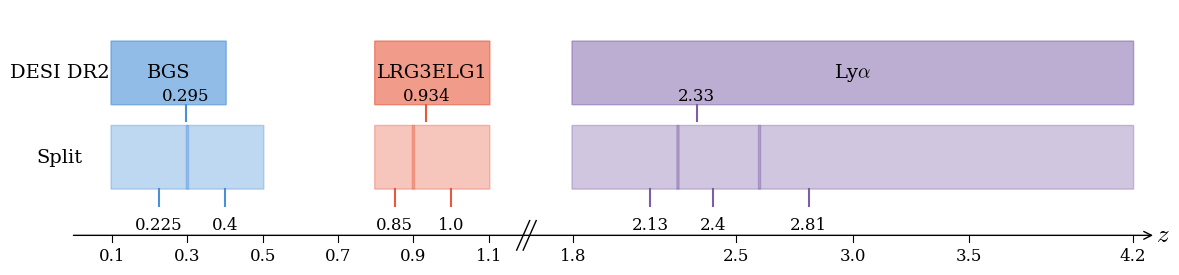

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
def plot_redshift_bins(savepath=None, overwrite=False, dpi=200):

    fig, ax = plt.subplots(figsize=(12, 3))

    # --- color palette ---
    c_bgs  = '#4A90D9'
    c_lrg  = '#E8593C'
    c_lya  = '#7B5EA7'

    # --- bin definitions ---
    # DESI DR2
    dr2_bins = [
        (0.1,  0.4,  0.295, c_bgs, 'BGS',      0.6),
        (0.8,  1.1,  0.934, c_lrg, 'LRG3ELG1',  0.6),
        (1.8,  4.2,  2.33,  c_lya, r'Ly$\alpha$', 0.5),
    ]
    # Split
    split_bins = [
        (0.1,  0.3,  0.225, c_bgs, '',         0.35),
        (0.3,  0.5,  0.4,   c_bgs, '',         0.35),
        (0.8,  0.9,  0.85,  c_lrg, '',         0.35),
        (0.9,  1.1,  1.0,   c_lrg, '',         0.35),
        (1.8,  2.25, 2.13,  c_lya, '',         0.35),
        (2.25, 2.6,  2.4,   c_lya, '',         0.35),
        (2.6,  4.2,  2.81,  c_lya, '',         0.35),
    ]

    row_y    = {'dr2': 0.55, 'split': 0.15}
    row_h    = 0.30
    zeff_dy  = 0.08   # tick drop below bar
    label_dy = 0.13   # z_eff label drop below bar

    # --- axis break setup ---
    # We display two segments: [0.0, 1.3] and [1.6, 4.4]
    # mapped linearly within the axes using a transform
    seg1 = (-0.01,  1.2)
    seg2 = (1.6,  4.3)
    frac = 0.42   # fraction of axis width given to segment 1

    def z_to_x(z):
        """Map redshift to axes x coordinate [0,1]."""
        if z <= seg1[1]:
            return frac * (z - seg1[0]) / (seg1[1] - seg1[0])
        else:
            return frac + (1 - frac) * (z - seg2[0]) / (seg2[1] - seg2[0])

    def draw_bin(z_lo, z_hi, z_eff, color, label, alpha, y, h, show_label=True, label_pos='bottom'):
            x0 = z_to_x(z_lo)
            x1 = z_to_x(z_hi)
            rect = mpatches.FancyBboxPatch(
                (x0, y), x1 - x0, h,
                boxstyle='round,pad=0.001',
                linewidth=1, edgecolor=color,
                facecolor=color, alpha=alpha,
                transform=ax.transAxes, clip_on=False
            )
            ax.add_patch(rect)
            if label:
                ax.text((x0 + x1) / 2, y + h / 2, label,
                        transform=ax.transAxes, ha='center', va='center',
                        fontsize=14, color='black')#, fontweight='bold')
            # z_eff tick and label
            xe = z_to_x(z_eff)
            if label_pos == 'bottom':
                ax.plot([xe, xe], [y - zeff_dy, y], transform=ax.transAxes,
                        color=color, lw=1.5, clip_on=False)
                if show_label:
                    ax.text(xe, y - label_dy, f'{z_eff}',
                            transform=ax.transAxes, ha='center', va='top',
                            # fontsize=12, color=color)
                            fontsize=14, color='black')
            else:  # top
                ax.plot([xe, xe], [y-zeff_dy, y], transform=ax.transAxes,
                        color=color, lw=1.5, clip_on=False)
                if show_label:
                    ax.text(xe, y + label_dy -0.13, f'{z_eff}',
                            transform=ax.transAxes, ha='center', va='bottom',
                            # fontsize=11, color=color, alpha=1)
                            fontsize=14, color='black', alpha=1)
            

    # draw bars
    for (z0, z1, ze, c, lbl, alp) in dr2_bins:
        draw_bin(z0, z1, ze, c, lbl, alp, row_y['dr2'], row_h, label_pos='top')
    for (z0, z1, ze, c, lbl, alp) in split_bins:
        draw_bin(z0, z1, ze, c, lbl, alp, row_y['split'], row_h, label_pos='bottom')

    # --- row labels ---
    ax.text(-0.01, row_y['dr2']  + row_h / 2, 'DESI DR2',
            transform=ax.transAxes, ha='center', va='center', fontsize=14)
    ax.text(-0.01, row_y['split'] + row_h / 2, 'Split',
            transform=ax.transAxes, ha='center', va='center', fontsize=14)

    # --- z axis ticks ---
    z_ticks = [0.1, 0.3, 0.5, 0.7, 0.9, 1.1, 1.8, 2.0, 2.5, 3.0, 3.5, 4.0]
    z_ticks = [0.1, 0.3, 0.5, 0.7, 0.9, 1.1, 1.8, 2.5, 3.0, 3.5, 4.2]
    ax_y_tick = row_y['split'] - 0.22

    ax.annotate('', xy=(1.0, ax_y_tick), xytext=(0.0, ax_y_tick), # arrow axis
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='black', lw=1))
    
    for z in z_ticks:
        if z <= seg1[1] or z >= seg2[0]:
            x = z_to_x(z)
            ax.plot([x, x], [ax_y_tick - 0.03, ax_y_tick],
                    transform=ax.transAxes, color='black', lw=0.8, clip_on=False)
            ax.text(x, ax_y_tick - 0.06, f'{z}',
                    transform=ax.transAxes, ha='center', va='top', fontsize=14)

    ax.text(1.0, ax_y_tick, '$z$', transform=ax.transAxes,
            ha='left', va='center', fontsize=18)

    # --- axis break marks //  ---
    break_x = frac
    # for dy in [-0.05, 0.0, 0.05]:
    for dy in [-0.03, 0.03]:
        y_c = ax_y_tick + dy
        ax.plot([break_x - 0.005, break_x + 0.005],
                [y_c - 0.07, y_c + 0.07],
                transform=ax.transAxes, color='white', lw=4, clip_on=False)
        # ax.plot([break_x - 0.006, break_x + 0.006],
        #         [y_c - 0.1, y_c + 0.1],
        #         transform=ax.transAxes, color='black', lw=1, clip_on=False)
    
    y_spread = 0.07
    ax.plot([break_x - 0.009, break_x + 0.003],
            [ax_y_tick - y_spread, ax_y_tick + y_spread],
            transform=ax.transAxes, color='black', lw=1, clip_on=False)
    ax.plot([break_x - 0.003, break_x + 0.009],
            [ax_y_tick - y_spread, ax_y_tick + y_spread],
            transform=ax.transAxes, color='black', lw=1, clip_on=False)

    ax.axis('off')
    fig.tight_layout()

    if savepath is not None:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        if not os.path.exists(savepath) or overwrite:
            fig.savefig(savepath, dpi=dpi, bbox_inches='tight')
            if overwrite and os.path.exists(savepath):
                print(f'Overwriting {savepath}')
        else:
            print(f'File {savepath} already exists, set overwrite=True to overwrite.')

    plt.show()

plot_redshift_bins(savepath=path_to_fig + r'\illustrations\split_redshift_bins.pdf')#, overwrite=True)